# Introduction / Objective of this notebook

The goal of this project is to match resumes to job descriptions using a combination of embedding-based retrieval and large language model (LLM) analysis. The system first computes semantic similarity between resumes and job descriptions using embeddings, then leverages an LLM to provide contextual explanations for the ranking and relevance of the matches.

This notebook focuses on evaluating the system qualitatively. Since there are no pre-existing labeled matches between resumes and job descriptions, we cannot compute traditional accuracy metrics. Instead, we will demonstrate the model’s behavior through example queries, highlighting top-ranked resumes for a selection of job descriptions and analyzing their relevance scores.

Additionally, we will assess the performance of the system by measuring query latency, both for individual queries and small batches, to provide insights into the efficiency of the retrieval and LLM explanation pipeline.

# Dataset overview (after transformation)

In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets
job_postings = pd.read_csv("../data/jobs/job_postings.csv")
resumes = pd.read_csv("../data/resumes/resumes.csv")

In [3]:
# Samples to see what the dataset look like
print("=== Sample Job Postings ===")
display(job_postings.head())

print("\n=== Sample Resumes ===")
display(resumes.head())

=== Sample Job Postings ===


,Unnamed: 0,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0



=== Sample Resumes ===


,Category,Text
0,Accountant,education omba executive leadership university...
1,Accountant,howard gerrard accountant deyjobcom birmingham...
2,Accountant,kevin frank senior accountant inforesumekraftc...
3,Accountant,place birth nationality olivia ogilvy accounta...
4,Accountant,stephen greet cpa senior accountant 9 year exp...


These are the original datasets. Before being fed to the LLM, some of the columns in the job description had to be merged into a single string (see ingestion/preprocessing.py), like this :

In [4]:
fields_to_combine = [
    "title",
    "location",
    "description",
    "requirements",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"# Sales, Engeneering, ...
]
row = job_postings.head(1)

for f in fields_to_combine:
    field_content = row.get(f, "").iloc[0]
    if field_content == float('nan'):
        pass
    clean_field_content = re.sub(r"\s+", " ", str(field_content))
    combined_text = ". ".join([f + ": " + clean_field_content for f in fields_to_combine])
print(combined_text)

title: Marketing. location: Marketing. description: Marketing. requirements: Marketing. employment_type: Marketing. required_experience: Marketing. required_education: Marketing. industry: Marketing. function: Marketing


Here are some basic statistics on our dataset :

In [5]:
# Basic statistics
num_jobs = len(job_postings)
num_resumes = len(resumes)

# Assuming job descriptions are in a column named 'description'
# and resumes are in a column named 'content'
avg_job_length = job_postings['description'].apply(lambda x: len(str(x).split())).mean()
avg_resume_length = resumes['Text'].apply(lambda x: len(str(x).split())).mean()

print("=== Dataset Statistics ===")
print(f"Number of job postings: {num_jobs}")
print(f"Number of resumes: {num_resumes}")
print(f"Average job description length (words): {avg_job_length:.1f}")
print(f"Average resume length (words): {avg_resume_length:.1f}")

=== Dataset Statistics ===
Number of job postings: 17014
Number of resumes: 13389
Average job description length (words): 171.0
Average resume length (words): 474.9


In [6]:
# Fill missing categories
job_postings['title'] = job_postings['title'].fillna('Unknown')
resumes['Category'] = resumes['Category'].fillna('Unknown')

# And clean weird input
job_postings_clean = job_postings[~job_postings['title'].str.contains(r'\$', regex=True, na=False)]
resumes_clean = resumes[~resumes['Category'].str.contains(r'\$', regex=True, na=False)]

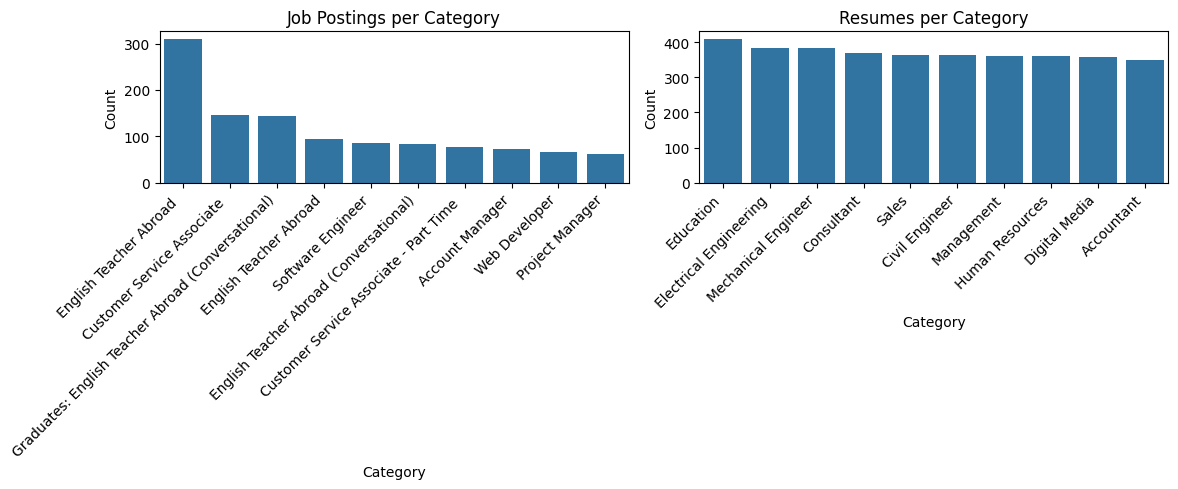

In [7]:
# Get top 10 most frequent titles/categories
top10_jobs = job_postings_clean['title'].value_counts().nlargest(10).index
top10_resumes = resumes_clean['Category'].value_counts().nlargest(10).index

# Barplots of category counts
plt.figure(figsize=(12,5))

# Job postings category count
plt.subplot(1, 2, 1)
sns.countplot(
    data=job_postings_clean[ job_postings_clean['title'].isin(top10_jobs) ], 
    x='title', 
    order=top10_jobs)
plt.title('Job Postings per Category')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.xlabel('Category')

# Resumes category count
plt.subplot(1, 2, 2)
sns.countplot(
    data=resumes_clean[resumes_clean['Category'].isin(top10_resumes)], 
    x='Category', 
    order=top10_resumes)
plt.title('Resumes per Category')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.xlabel('Category')

plt.tight_layout()
plt.show()

While the resume categories are pretty well distributed, we can see that the job posting contains a lot of english teacher jobs.

# Matching example

Here is an example of how our model matches a new resume to existing job descriptions (the inverse being very similar).

In [9]:
import sys
import json
from pathlib import Path
import importlib
project_root = Path("..").resolve()
sys.path.append(str(project_root))

In [10]:
# Load the necessary files
import ingestion.preprocess
import agents.normalization_agent
import agents.fixing_agent
import embeddings.embedding_engine
import embeddings.embedding_format_conversion
import match_engine_and_explanation.match_engine
import match_engine_and_explanation.llm_explanation
# Reload the file to take into account the changes (if necessary)
importlib.reload(ingestion.preprocess)
importlib.reload(agents.normalization_agent)
importlib.reload(agents.fixing_agent)
importlib.reload(embeddings.embedding_engine)
importlib.reload(embeddings.embedding_format_conversion)
importlib.reload(match_engine_and_explanation.match_engine)
importlib.reload(match_engine_and_explanation.llm_explanation)

C:\Users\Sebastien\Desktop\LLM and GenAI\Smart_Resume_to_Job_Matcher\agents\normalization_agent.py:113: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(
W0121 23:53:04.828000 20392 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
C:\Users\Sebastien\Desktop\LLM and GenAI\Smart_Resume_to_Job_Matcher\embeddings\embedding_engine.py:30: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from 

<module 'match_engine_and_explanation.llm_explanation' from 'C:\\Users\\Sebastien\\Desktop\\LLM and GenAI\\Smart_Resume_to_Job_Matcher\\match_engine_and_explanation\\llm_explanation.py'>

In [187]:
# Import the necessary functions
from ingestion.preprocess import any_resume_to_raw_text
from agents.normalization_agent import normalize_resume
from agents.fixing_agent import fix_error_experience, fix_error_education
from embeddings.embedding_engine import embed_resume_BGE, embed_job_BGE
from embeddings.embedding_format_conversion import lists_to_id_vector_dicts
from match_engine_and_explanation.match_engine import eucl_distance, cosine_similarity, match_jobs_to_resume, match_resumes_to_job
from match_engine_and_explanation.llm_explanation import generate_match_explanation

In [12]:
# We take a sample resume (.pdf for example) 
sample_resume_path = "../data/test/Resume_3.pdf"

**Here is the full pipeline** (on a smaller dataset for faster inference)

Choosing a smaller dataset may make the LLM less useful, because the selection was done randomly, but here, we mainly care about the computation.

In [13]:
# We first load the precomputed jobs embeddings (reduced for speed)
job_emb_path = Path("../notebooks/checkpoints_test/jobs_embeddings_bge_small.json")

with open(job_emb_path, "r") as f:
    emb_job = json.load(f)

In [14]:
# We also need to convert it into a dictionnary for compatibility
_, emb_job_dic = lists_to_id_vector_dicts({}, emb_job)

In [15]:
# Ingestion 
## We need to transform the file into raw text
raw_text = any_resume_to_raw_text(sample_resume_path)[0]
## Then normalize said text
norm_text = normalize_resume(raw_text)
## Sometime, the normalized text will have errors in some fields that we need to fix
norm_text = fix_error_experience( fix_error_education(norm_text))

In [ ]:
# Embedding
vec = embed_resume_BGE(norm_text)

In [ ]:
# Compute the matches with chosen similarity function
similarity_func = eucl_distance
top_k = 5 # We take the five best job descriptions
matches = match_jobs_to_resume(None, vec, emb_job_dic, similarity_func, top_k)

In [19]:
# We get the best match accross all job descriptions
## For this, we need the normalized path to said job
with open(Path("../notebooks/checkpoints_test/normalized_jobs_small.json"), "r") as f:
    normalized_jobs = json.load(f)
## Get the best job id
best_match = matches[0]
job_id, score = best_match["job_id"], best_match["score"]
## Get its description
for job in normalized_jobs:
    if job.get('job_id') == job_id:
        job_description = job['job_description']

In [22]:
print(norm_text)
print(score)
print(job_description)

{'skills': ['Microsoft Office', 'Strategic Planning', 'Economic Analysis', 'Statistical Analysis', 'Business Analysis', 'Drafting Strategic Documents'], 'experience': ['at Verizon Communications (2008-2010) : Evaluated and documented data on international trade, macroeconomic indicators, housing prices, value amenities, location, food, and consumer behavior.', 'at City of Redondo Beach (2009-2010) : Evaluated and documented data on consumer economic research analysis, forecasting, city-state evaluated data on consumer behavior, exchange rates, food, durable goods prices, sales, housing starts, house prices, credit conditions.'], 'education': ['Master of Science in Agricultural Economics from Imperial College London (2008)', 'Bachelor of Arts in International Relations from Kingston University London (2007)'], 'certifications': [], 'industries': ['Agriculture', 'Finance', 'Government']}
0.9846745795216147
{'job_title': 'Commissioning Machinery Assistant', 'required_skills': ['supervisor

In [23]:
# We generate the LLM explanation (Here only for the best match)
explanation = generate_match_explanation(
                job_description,
                norm_text,
                score
            )
print(explanation)

Based on the provided job description and candidate profile, I would rate the similarity score as 0.985.

Key Strengths:

* The candidate has relevant experience in evaluating and documenting data, which aligns with the job requirement of attention to detail.
* Their education background in Agricultural Economics and International Relations demonstrates a strong foundation in economic analysis, which is a key skill required for the job.
* The candidate's experience working with macroeconomic indicators, housing prices, and consumer behavior at Verizon Communications and City of Redondo Beach shows their ability to work with complex data sets.

Gaps or Risks:

* Although the candidate has experience in strategic planning and drafting documents, there is no direct mention of supervisory skills, which is a critical requirement for the job.
* The candidate's industry experience is primarily in Agriculture, Finance, and Government, whereas the job description specifies Engineering and Const

# Qualitative evaluation and Relevance scoring

In [45]:
# Import embeddings and normalized files
job_emb_path = Path("../notebooks/checkpoints_test/jobs_embeddings_bge_small.json")
resume_emb_path = Path("../notebooks/checkpoints_test/resume_embeddings_bge_small.json")
norm_jobs_path = Path("../notebooks/checkpoints_test/normalized_jobs_small.json")
norm_resumes_path = Path("../notebooks/checkpoints_test/normalized_resumes_small.json")

with open(job_emb_path, "r") as f:
    emb_jobs = json.load(f)
with open(resume_emb_path, "r") as f:
    emb_resumes = json.load(f)
with open(norm_jobs_path, "r") as f:
    norm_jobs = json.load(f)
with open(norm_resumes_path, "r") as f:
    norm_resumes = json.load(f)

In [31]:
import random as rd

## Match jobs to a resume

In this part, we will choose one random resume and 5 random job descriptions. 

Then, before computation, we will rank those manually and compare our ranking with the LLM's ranking and explanation to see if they fit.

In [107]:
# Choosing one random resume and 5 random job descriptions
resume_id = 57# taken randomly but fixed
job_ids = [10, 4, 6, 79, 61]# same

In [ ]:
# Display the associated descriptions
print("---- RESUME -----")
for res in norm_resumes:
    if res['resume_id'] == resume_id:
        norm_resume_text = res['norm_text']
        for k in norm_resume_text.keys():
            print(k, ":", norm_resume_text[k])
            
print("---------------------------")
print("---- JOB DESCRIPTIONS -----")
job_descriptions = {}
for job in norm_jobs:
    if job['job_id'] in job_ids:
        description = job['job_description']
        job_descriptions[job['job_id']] = description
        for k in description.keys():
            print(k, ":", description[k])
        print()

---- RESUME -----
skills : ['Microsoft Office', 'Advanced Excel Skills', 'Professional Fluent German', 'Franch Spanish', 'People Management', 'Credit Control', 'Balance Sheet Reconciliations', 'Account Queries']
experience : ['Smiths Accounts, Birmingham - Accountant (Jun 2013-Present): Responsible for full range of financial reporting carried out within various departments. Duties include preparing quality-focused analytical reviews to support financial reporting and implementing necessary changes required for finance operations across the company.']
education : ['BSc Hons in Accounting, Nuneaton University (2008-2011)']
certifications : []
industries : []
---------------------------
---- JOB DESCRIPTIONS -----
job_title : Account Executive
required_skills : ['Enterprise sales experience', 'Platform solutions to businesses', 'Insight selling methodologies', 'Strong partnerships and advocacy with customers', 'Excellent presentation, white boarding, and negotiation skills']
required_exp

Choosen ranking :
- Accounting Clerk (6)
- Account Executive (4)
- Business Development Manager (79)
- Customer Service Representative (10)
- English Teacher (61)

In [ ]:
# Actual ranking
## Embedding
vec = embed_resume_BGE(norm_text)
emb_job_dic = {id:embed_job_BGE(job) for id, job in job_descriptions.items()}

## Compute the matches with chosen similarity function
similarity_func = cosine_similarity
top_k = 5
matches = match_jobs_to_resume(resume_id, vec, emb_job_dic, similarity_func, top_k)

## Actual ranking
for match in matches:
    print(match)

{'job_id': 61, 'resume_id': 57, 'score': 0.9182228618440202}
{'job_id': 79, 'resume_id': 57, 'score': 0.9059576390566134}
{'job_id': 6, 'resume_id': 57, 'score': 0.8514819941890379}
{'job_id': 10, 'resume_id': 57, 'score': 0.8487769871826972}
{'job_id': 4, 'resume_id': 57, 'score': 0.8430384543519092}


Now, we compute the Spearman correlation between our two ranking.

In [12]:
elements = [4, 6, 10, 61, 79]
my_ranking = np.array([2, 1, 4, 5, 3])
LLM_ranking = np.array([5, 3, 4, 1, 2])
n = len(elements)
# Computation
d = my_ranking - LLM_ranking
sum_of_squared = sum(d**2)
spearman_corr = 1 - (6*sum_of_squared)/(n*(n**2 - 1))

print(spearman_corr)

-0.5


Providing the LLM expanation for the best ranking.

In [125]:
# We generate the LLM explanation (Here only for the best match)
best_id = matches[0]['job_id']
score = matches[0]['score']

explanation = generate_match_explanation(
                job_descriptions[best_id],
                norm_text,
                score
            )
print(explanation)

Based on the provided job description and candidate profile, I would rate the similarity score as 0.918.

Key Strengths:

* The candidate has a strong educational background in international relations and agricultural economics, which aligns with the industry of education.
* They possess skills in statistical analysis, business analysis, and drafting strategic documents, which could be valuable in an English teacher role.
* Their experience in evaluating and documenting data on consumer behavior, economic indicators, and forecasting could translate to analyzing student performance and developing teaching strategies.

Gaps or Risks:

* The candidate's work experience is primarily in industries outside of education (Agriculture, Finance, Government), which may not directly apply to the English teacher role.
* There is no direct mention of TEFL, TESOL, or CELTA certifications, although their skills and experience could be relevant.

Overall Suitability:

The candidate's profile shows a st

Due the the bad initial ranking, the LLM hallucinates a few elements, notably the background in agricultural economics mentionned neither in the resume nor the job description (though it is mentionned there to be in the industry of environmental consulting).

The LLM doesn't seem to contradict us even when the absence of match is obvious, mainly because the prompt was built to encourage positive feedback over direct reject. The score given to the LLM about the match further insists on that point.

## Match resumes to a job

In this part, we will do the same but choosing one random job description and 5 random resumes.

In [182]:
# Choosing one random job description and five random resumes
job_id = 86# taken randomly but fixed
resume_ids = [18, 20, 33, 71, 68]# same

In [ ]:
# Display the associated descriptions
print("---- JOB DESCRIPTION -----")
for job in norm_jobs:
    if job['job_id'] == job_id:
        job_description = job['job_description']
        for k in job_description.keys():
            print(k, ":", job_description[k])
            
print("---------------------------")
print("---- RESUMES -----")
resumes = {}
for res in norm_resumes:
    if res['resume_id'] in resume_ids:
        text = res['norm_text']
        resumes[res['resume_id']] = text
        for k in text.keys():
            print(k, ":", text[k])
        print()

Choosen ranking :
- Financial Analyst (20)
- Junior Accountant (33)
- Audit Assistant (18)
- Advocate (71)
- Criminal Lawyer (68)

In [189]:
# Actual ranking
## Embedding
vec = embed_job_BGE(job_description)
emb_resume_dic = {id:embed_resume_BGE(resume) for id, resume in resumes.items()}

## Compute the matches with chosen similarity function
similarity_func = eucl_distance
top_k = 5 # We take the five best job descriptions
matches = match_resumes_to_job(job_id, vec, emb_resume_dic, similarity_func, top_k)

## Actual ranking
for match in matches:
    print(match)

{'job_id': 86, 'resume_id': 18, 'score': 0.8927198014654683}
{'job_id': 86, 'resume_id': 68, 'score': 0.8519309018270819}
{'job_id': 86, 'resume_id': 33, 'score': 0.8298657345852338}
{'job_id': 86, 'resume_id': 71, 'score': 0.8213946495604403}
{'job_id': 86, 'resume_id': 20, 'score': 0.7959966648572425}


Now, we compute the Spearman correlation between our two ranking.

In [13]:
elements = [18, 20, 33, 68, 71]
my_ranking = np.array([3, 1, 2, 5, 4])
LLM_ranking = np.array([1, 5, 3, 2, 4])
n = len(elements)
# Computation
d = my_ranking - LLM_ranking
sum_of_squared = sum(d**2)
spearman_corr = 1 - (6*sum_of_squared)/(n*(n**2 - 1))

print(spearman_corr)

-0.5


Again, not really what I was expecting, except for the resumes 33 and 18 which are pretty high.

In [191]:
# We generate the LLM explanation (Here only for the best match)
best_id = matches[0]['resume_id']
score = matches[0]['score']

explanation = generate_match_explanation(
                job_description,
                resumes[best_id],
                score
            )
print(explanation)

Based on the job description and candidate profile, I would rate the similarity score as 0.893.

Key Strengths:

* The candidate has experience in financial modeling and valuation skills, which aligns with the job requirement.
* Their background in finance, as a Chartered Accountant, is relevant to the industry.
* They have strong analytical skills, which can be applied to the role.
* The candidate's attention to detail, organization, and communication skills are valuable assets.

Gaps or Risks:

* Although the candidate has experience in financial modeling, it is not explicitly stated that they have worked with R (the programming language) before. This might require additional training or onboarding.
* The candidate's industry experience is primarily in manufacturing and service, whereas the job description specifies Financial Services. While this can be transferable, there may be a need for additional learning or adaptation.

Overall Suitability:

The candidate's skills, education, a

Evident hallucination there is no mention of R in the job description yet it is said to be a requirement in this explanation. No mention of analytical or finance skills were mentioned in the resume either.

This might be because the score insentivises the LLM to say positive things about the candidate when this score is not really justified by the content of the resume.

# Latency / Performance analysis

These measure were taken via manual measure on the streamlit app

First, we have the latency given the number of files we asked the LLM to rank.

In [ ]:
# Latency distribution VS number of files (txt files, BGE embedding, cosine similarity)
## K matches
k_matches = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
## Resume -> Match jobs
resume_duration_s = [23, 31, 39, 47, 53, 61, 69, 77, 85, 91]
## Job -> Match resumes
job_duration_s = [20, 28 ,35, 43, 49, 55, 62, 71, 79, 86]

# --- Combine into long-form DataFrame ---
df = pd.DataFrame({
    'Top K': k_matches * 2,  # repeat K for both series
    'Duration (s)': resume_duration_s + job_duration_s,
    'Type': ['Resume → Job']*len(k_matches) + ['Job → Resume']*len(k_matches)
})

# --- Plot ---
plt.figure(figsize=(10,5))
sns.barplot(x='Top K', y='Duration (s)', hue='Type', data=df, palette='viridis')

# Add titles and labels
plt.title('Total processing Time vs Top-K Matches')
plt.xlabel('Top K Matches')
plt.ylabel('Duration (s)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Match Direction')
plt.tight_layout()
plt.show()

![Processing Time vs Top-K Matches](images\Processing_time_top_k_matches.png)

The plot seems to be pretty linear. That is not really surprising as resumes and jobs seem to all have approximately the same size. However, resumes are also proportionally longer than job descriptions.

Then, we try seeing if there is a correlation between document size and processing time. (yes with very little examples)

In [ ]:
# Processing time VS file type (1 match, BGE embedding, cosine similarity)
file_type = ['txt', 'docx', 'pdf']
## Resume -> Match jobs
resume_duration_s = [6.9, 6.5, 5.82]
## Job -> Match resumes
job_duration_s = [3.81, 3.89, 5.48]

## Issue : Other factors are not taken into account : the variation of my reaction time to measure this, 
##         but also and mainly the size of the documents that are precessed
## That is why we are adding the file size (kb) to get another view of the plot
resume_file_size = [7, 15, 26]
job_file_size = [3, 18, 64]


### PLOT
x = np.arange(len(file_type))  # the label locations
width = 0.35  # width of the bars

fig, ax1 = plt.subplots(figsize=(8,5))

# --- Bar plots for processing time ---
bars1 = ax1.bar(x - width/2, resume_duration_s, width, label='Resume → Job', color='blue', alpha=0.7)
bars2 = ax1.bar(x + width/2, job_duration_s, width, label='Job → Resume', color='orange', alpha=0.7)

ax1.set_xlabel('File Type')
ax1.set_ylabel('Processing Time (s)')
ax1.set_xticks(x)
ax1.set_xticklabels(file_type)
ax1.set_title('Processing Time vs File Type (1 match, BGE embedding, Cosine Similarity)')
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Secondary axis for file size ---
ax2 = ax1.twinx()
ax2.plot(x, resume_file_size, marker='o', color='blue', linestyle='--', label='Resume File Size (KB)')
ax2.plot(x, job_file_size, marker='s', color='orange', linestyle='--', label='Job File Size (KB)')
ax2.set_ylabel('File Size (KB)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

![Processing Time vs File Type](images\Processing_time_per_file_type.png)

There is the processing time, divided into the different steps of the pipeline.

In [201]:
# Average latency per step (1 match, BGE embedding, cosine similarity)
steps = ['Load embeddings', 'Load normalized text', 'File save', 'Ingestion + normalization', 'Embedding generation', 'Matching + LLM explanation', 'TOTAL']
file_types  = ['txt', 'docx', 'pdf']

# Latencies
latencies_resume = [ 
    [8.979, 9.496, 9.248],  # Load embeddings
    [0.54, 0.561, 0.49],    # Load normalized text
    [0, 0, 0],               # File save
    [6.907, 5.817, 6.552],  # Ingestion + normalization
    [0.076, 0.109, 0.115],  # Embedding generation
    [7.187, 9.266, 8.128],  # Matching + LLM explanation
    [23.689, 25.249, 24.533] # TOTAL
]
latencies_job = [
    [9.722, 9.283, 9.428],
    [0.49, 0.488, 0.438],
    [0.002, 0.002, 0],
    [2.752, 2.498, 3.175],
    [0.05, 0.052, 0.045],
    [7.106, 7.242, 7.158],
    [20.121, 19.565, 20.243]
]

In [ ]:
# --- Prepare long-form DataFrame ---
data = []

for i, step_name in enumerate(steps):
    for ft, res_val, job_val in zip(file_types, latencies_resume[i], latencies_job[i]):
        data.append({'Step': step_name, 'File Type': ft, 'Latency (s)': res_val, 'Direction': 'Resume → Job'})
        data.append({'Step': step_name, 'File Type': ft, 'Latency (s)': job_val, 'Direction': 'Job → Resume'})

df = pd.DataFrame(data)

# --- Plot ---
plt.figure(figsize=(12,6))
sns.barplot(x='Step', y='Latency (s)', hue='File Type', data=df, ci=None, palette='Set2')
plt.title('Average Latency per Pipeline Step (1 match)')
plt.xlabel('Pipeline Step')
plt.ylabel('Latency (s)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='File Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

![Latency per step](images\Latency_per_step.png)

Cold start VS Hot start

In [ ]:
# Latency for each query accross time (5 matches of Resume -> Job, BGE embedding, euclidian similarity, PDF file)
query_number = [1, 2, 3, 4, 5, 6]
tot_latency = [56.318, 52.362, 52.182, 52.404, 53.175, 53.108]

# Simulate cold vs hot (first query = cold, rest = hot)
cold_latency = [tot_latency[0]] + [None]*(len(tot_latency)-1)  # only first query
hot_latency = [None] + tot_latency[1:]  # remaining queries

# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(query_number, tot_latency, marker='o', linestyle='-', color='gray', label='Total Latency')
plt.plot(query_number, cold_latency, marker='o', linestyle='', color='red', markersize=8, label='Cold Start')
plt.plot(query_number, hot_latency, marker='o', linestyle='', color='blue', markersize=8, label='Hot Start')

plt.title('Latency per Query: Cold vs Hot Start')
plt.xlabel('Query Number (Same query)')
plt.ylabel('Latency (s)')
plt.xticks(query_number)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

![Latency per query](images\Cold_vs_Hot_start.png)

Similarity distribution example

![Similarity distribution](images\Similarity_distribution.png)